# Avaliação de métricas

Notebook pedagógico que percorre **etapa a etapa** o módulo [`metricas.py`](../src/metricas.py).

Cadeia de notebooks: [`extracao_embedding.ipynb`](extracao_embedding.ipynb) → [`compressao_tokens.ipynb`](compressao_tokens.ipynb) → **este notebook** → [`experimento.ipynb`](experimento.ipynb) → [`trabalho_final.ipynb`](trabalho_final.ipynb).

**Avaliação dual do trabalho:**

- **(A) Algébrica:** compressão $C$; para SVD, $E_k$ (energia espectral) e $R_k$ (fidelidade de $F_k$).
- **(B) Downstream:** pooling médio + $L_2$ → Ridge → acurácia IMDb.

Pré-requisito: $F$ podado via [`compressores.py`](../src/compressores.py) (ver [`compressao_tokens.ipynb`](compressao_tokens.ipynb)). Orquestração da grade em [`experimento.ipynb`](experimento.ipynb); validação vs artigo em [`trabalho_final.ipynb`](trabalho_final.ipynb).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

_raiz = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "notebook_setup.py").exists()
)
sys.path.insert(0, str(_raiz))
import notebook_setup
notebook_setup.configurar()

import dados
import embeddings
import compressores as cp
import metricas
from constantes import MAX_AMOSTRAS, MAX_TOKENS, N_POR_CLASSE, ORCAMENTOS, RIDGE_LAMBDA, SEED

RHO_DEMO = 0.5

print("Diretório de trabalho:", os.getcwd())

Diretório de trabalho: /home/THIAGO.OUVERNEY/Projects/ALC/Trabalho_Final/svd-leverage-token-compression


## 1. Dados — $F$, poda e `info`

Carregamos uma review IMDb, extraímos $F$ e aplicamos `comprimir_svd` com $\rho=0{,}5$ para obter $F_{\mathrm{pod}}$, `info` ($k$, `energia_explicada`, `reconstrucao` = $F_k$).

In [2]:
textos, rotulos = dados.carregar_imdb(
    n_por_classe=N_POR_CLASSE, max_amostras=MAX_AMOSTRAS, semente_split=SEED,
)
F = embeddings.texto_para_embedding(textos[0], max_tokens=MAX_TOKENS)
T, D = F.shape

indices_svd, F_pod, info_svd = cp.comprimir_svd(F, orcamento=RHO_DEMO)
F_k = info_svd["reconstrucao"]
T_prime = len(indices_svd)

print(f"F: ({T}, {D})  |  F_pod: {F_pod.shape}  |  F_k: {F_k.shape}")
print(f"k={info_svd['k']}  |  rho={RHO_DEMO}  |  T'={T_prime}")

/home/THIAGO.OUVERNEY/Projects/ALC/Trabalho_Final/svd-leverage-token-compression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13567.41it/s]

F: (254, 384)  |  F_pod: (127, 384)  |  F_k: (254, 384)
k=56  |  rho=0.5  |  T'=127


## 2. Compressão — `compressao`

$$C = 1 - \frac{T'}{T}$$

Mede **quantas linhas** (tokens) foram removidas. Depende de $\rho$ e de $T$. **Não** mede qualidade espectral nem acurácia.

C (rho=0.5): 0.500  (T'=127, T=254)

  rho=0.750  T'=190  C=0.252
  rho=0.500  T'=127  C=0.500
  rho=0.250  T'= 64  C=0.748
  rho=0.125  T'= 32  C=0.874


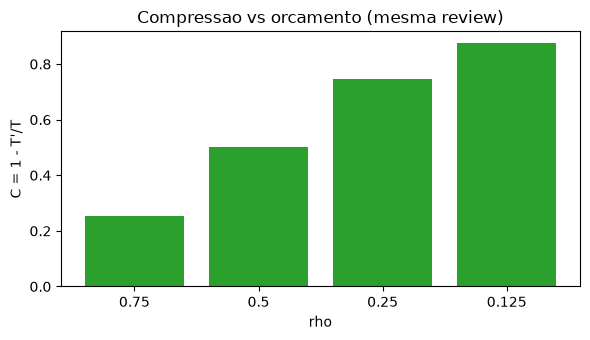

In [3]:
C_demo = metricas.compressao(T, T_prime)
print(f"C (rho={RHO_DEMO}): {C_demo:.3f}  (T'={T_prime}, T={T})\n")

rhos, Cs = [], []
for rho in ORCAMENTOS:
    t_m = cp._tokens_a_manter(T, rho)
    c = metricas.compressao(T, t_m)
    rhos.append(rho)
    Cs.append(c)
    print(f"  rho={rho:5.3f}  T'={t_m:3d}  C={c:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([str(r) for r in rhos], Cs, color="tab:green")
ax.set_xlabel("rho")
ax.set_ylabel("C = 1 - T'/T")
ax.set_title("Compressao vs orcamento (mesma review)")
plt.tight_layout()
plt.show()

## 3. Energia espectral — `energia_espectral_preservada` ($E_k$)

Lê `info['energia_explicada']` da SVD: fração de $\sum_j \sigma_j^2$ nos $k$ primeiros modos.

**O que mede:** subespaço truncado $F_k$ (posto $k$).  
**O que não mede:** qualidade da seleção de $T'$ linhas em $F[\mathrm{índices}]$.

E_k = 0.9506  (k=56)

E_k e k ao variar rho (mesmo F):
  rho=0.750  k= 56  E_k=0.9506
  rho=0.500  k= 56  E_k=0.9506
  rho=0.250  k= 56  E_k=0.9506
  rho=0.125  k= 56  E_k=0.9506


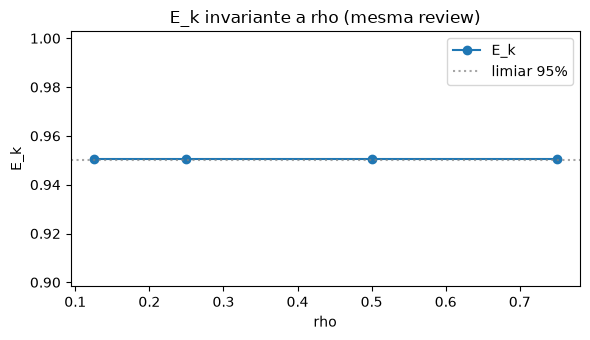

In [4]:
E_k = metricas.energia_espectral_preservada(info_svd)
print(f"E_k = {E_k:.4f}  (k={info_svd['k']})")

eks, ks = [], []
print("\nE_k e k ao variar rho (mesmo F):")
for rho in ORCAMENTOS:
    _, _, info = cp.comprimir_svd(F, orcamento=rho)
    ek = metricas.energia_espectral_preservada(info)
    eks.append(ek)
    ks.append(info["k"])
    print(f"  rho={rho:5.3f}  k={info['k']:3d}  E_k={ek:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(rhos, eks, marker="o", label="E_k")
ax.axhline(0.95, color="gray", linestyle=":", alpha=0.7, label="limiar 95%")
ax.set_xlabel("rho")
ax.set_ylabel("E_k")
ax.set_title("E_k invariante a rho (mesma review)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Fidelidade — `fidelidade_reconstrucao` ($R_k$)

$$R_k = 1 - \frac{\|F - F_k\|_F}{\|F\|_F}$$

Quão perto $F_k$ (`info['reconstrucao']`) está de $F$ **inteira**. Shape de $F_k$ é $(T, D)$ — todas as linhas, posto reduzido.

**Não** usa $F_{\mathrm{pod}}$ ($(T', D)$ linhas originais escolhidas).

In [8]:
R_k = metricas.fidelidade_reconstrucao(F, F_k)
erro_fk = np.linalg.norm(F - F_k)
norm_f = np.linalg.norm(F)
norm_fpod = np.linalg.norm(F_pod)

print(f"R_k = {R_k:.4f}")
print(f"||F_pod||_F = {norm_fpod:.2f}  (submatriz podada)")

R_k = 0.7777
||F_pod||_F = 64.98  (submatriz podada)


## 5. $E_k$ vs $R_k$ vs $C$ — o que muda com $\rho$

| Métrica | Depende de $\rho$? | Objeto |
|---------|-------------------|--------|
| $C$ | Sim | poda de linhas ($T'$) |
| $E_k$ | Não (mesmo $F$) | subespaço SVD ($k$ modos) |
| $R_k$ | Não (mesmo $F$) | reconstrução $F_k$ vs $F$ |
| Acurácia | Sim | $F_{\mathrm{pod}}$ → pooling → Ridge |

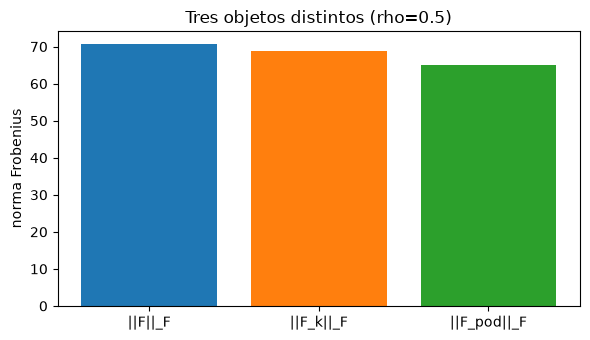

C=0.500  E_k=0.9506  R_k=0.7777


In [6]:
normas = {
    "||F||_F": norm_f,
    "||F_k||_F": np.linalg.norm(F_k),
    "||F_pod||_F": norm_fpod,
}

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(list(normas.keys()), list(normas.values()), color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel("norma Frobenius")
ax.set_title(f"Tres objetos distintos (rho={RHO_DEMO})")
plt.tight_layout()
plt.show()

print(f"C={C_demo:.3f}  E_k={E_k:.4f}  R_k={R_k:.4f}")

## 6. Pooling — passo de protocolo

Definido em [`experimento.py`](../src/experimento.py): média das linhas de $F_{\mathrm{pod}}$ e normalização $L_2$ → vetor $(D,)$ por review.

In [ ]:
def pooling(F_mat):
    v = F_mat.mean(axis=0)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v


v_full = pooling(F)
v_pod = pooling(F_pod)
print(f"pooling(F):     shape {v_full.shape}, norma {np.linalg.norm(v_full):.4f}")
print(f"pooling(F_pod): shape {v_pod.shape}, norma {np.linalg.norm(v_pod):.4f}")

## 7. Classificador — `classificador_ridge`

Wrapper sobre `sklearn.linear_model.RidgeClassifier` com `alpha=RIDGE_LAMBDA` (1.0) e `fit_intercept=True` (intercepto não regularizado). A função mantém a mesma assinatura usada em [`experimento.py`](../src/experimento.py).

In [ ]:
rng = np.random.default_rng(0)
X_toy = rng.standard_normal((8, 4))
y_toy = np.array([0, 0, 0, 0, 1, 1, 1, 1])
X_te_toy = rng.standard_normal((4, 4))

pred_toy = metricas.classificador_ridge(X_toy, y_toy, X_te_toy, lam=RIDGE_LAMBDA)
print(f"RIDGE_LAMBDA = {RIDGE_LAMBDA}")
print(f"Treino: {len(y_toy)} amostras, {X_toy.shape[1]} features")
print(f"Predicoes toy: {pred_toy}")

## 8. Acurácia — `acuracia`

Fração de acertos: $\frac{1}{n}\sum_i \mathbb{1}[\hat{y}_i = y_i]$.

In [ ]:
y_true_toy = np.array([0, 1, 0, 1])
y_pred_toy = np.array([0, 1, 1, 1])
print(f"Acuracia toy: {metricas.acuracia(y_true_toy, y_pred_toy):.3f}  (3/4)")

## 9. Mini downstream — pipeline integrado

Espelha a lógica de `_processar_amostras` em [`experimento.py`](../src/experimento.py) (passo a passo completo em [`experimento.ipynb`](experimento.ipynb)): $n=20$ reviews, `svd`, $\rho=0{,}5$, split estratificado.

In [ ]:
n_mini = 20
textos_mini = textos[:n_mini]
rotulos_mini = rotulos[:n_mini]
idx_tr, idx_te = dados.dividir_indices_estratificado(rotulos_mini, semente=SEED)
amostras_mini = [embeddings.texto_para_embedding(t, max_tokens=MAX_TOKENS) for t in textos_mini]

vetores_tr, vetores_te = [], []
for i, F_i in enumerate(amostras_mini):
    _, F_pod_i, info_i = cp.comprimir_svd(F_i, RHO_DEMO)
    v = pooling(F_pod_i)
    if i in set(idx_tr):
        vetores_tr.append(v)
    else:
        vetores_te.append(v)

X_tr = np.vstack(vetores_tr)
X_te = np.vstack(vetores_te)
y_tr, y_te = rotulos_mini[idx_tr], rotulos_mini[idx_te]
previsto = metricas.classificador_ridge(X_tr, y_tr, X_te)
acc_mini = metricas.acuracia(y_te, previsto)

_, _, info_mini0 = cp.comprimir_svd(amostras_mini[0], RHO_DEMO)
T0 = amostras_mini[0].shape[0]
T0p = cp._tokens_a_manter(T0, RHO_DEMO)

print(f"Mini-experimento (n={n_mini}, svd, rho={RHO_DEMO}):")
print(f"  Acuracia downstream: {acc_mini:.3f}")
print(f"  C (review 0):          {metricas.compressao(T0, T0p):.3f}")
print(f"  E_k (review 0):        {metricas.energia_espectral_preservada(info_mini0):.3f}")
print(f"  R_k (review 0):        {metricas.fidelidade_reconstrucao(amostras_mini[0], info_mini0['reconstrucao']):.3f}")

## 10. NaN em baselines — o que cada método reporta

Só `svd` / `svd_energia` preenchem `energia_explicada` e `reconstrucao`. Baselines retornam `nan` em $E_k$ e $R_k$; $C$ funciona para todos.

In [ ]:
print(f"{'metodo':12s}  C      E_k    R_k")
print("-" * 38)
for nome in ("full", "random", "svd"):
    fn = cp.COMPRESSORES[nome]
    idx, F_p, info = fn(F, RHO_DEMO, semente=0)
    c = metricas.compressao(T, len(idx))
    ek = metricas.energia_espectral_preservada(info)
    rk = metricas.fidelidade_reconstrucao(F, info.get("reconstrucao"))
    ek_s = f"{ek:.3f}" if not np.isnan(ek) else "nan"
    rk_s = f"{rk:.3f}" if not np.isnan(rk) else "nan"
    print(f"{nome:12s}  {c:.3f}  {ek_s:>5s}  {rk_s:>5s}")